In [1]:
import pandas as pd

# Load dataset

df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [2]:
df.shape

(5572, 5)

In [3]:
# Keep only useful columns

df = df[["v1", "v2"]]

# Rename columns to meaningful names

df.columns = ["label", "message"]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
# Convert spam/ham to numbers

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df["label"].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [8]:
import re

# Function to clean text

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r"[^a-zA-Z]", " ", text)
    
    text = re.sub(r"\s+", " ", text)
    
    return text

# Apply cleaning

df["clean_message"] = df["message"].apply(clean_text)

df.head()

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numeric form

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df["clean_message"]
)

y = df["label"]

print("Text vectorization completed!")

Text vectorization completed!


In [10]:
df.shape

(5572, 3)

In [11]:
df["label"].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data split completed!")

Data split completed!


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9641255605381166


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.73      0.85       150

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



In [16]:
# Test custom message

test_msg = ["Congratulations! You won a free ticket. Call now!"]

test_clean = [clean_text(msg) for msg in test_msg]

test_vector = vectorizer.transform(test_clean)

prediction = model.predict(test_vector)

if prediction[0] == 1:
    print("⚠️ Spam Message Detected")
else:
    print("✅ Normal Message")

⚠️ Spam Message Detected


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),  # unigrams + bigrams
    max_features=5000
)

X = vectorizer.fit_transform(df["clean_message"])

print("Improved vectorization completed!")

Improved vectorization completed!


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("New Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

New Accuracy: 0.9515695067264573
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.97      0.66      0.79       150

    accuracy                           0.95      1115
   macro avg       0.96      0.83      0.88      1115
weighted avg       0.95      0.95      0.95      1115



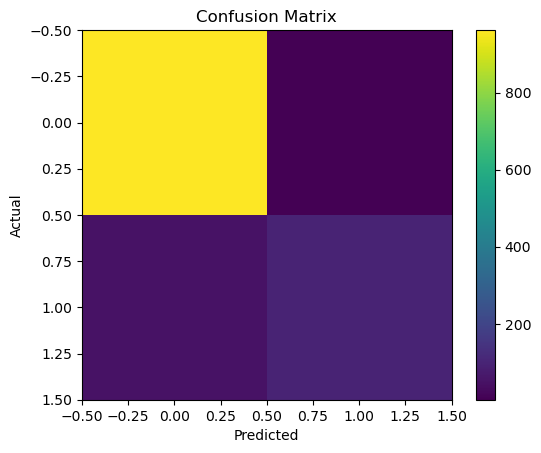

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

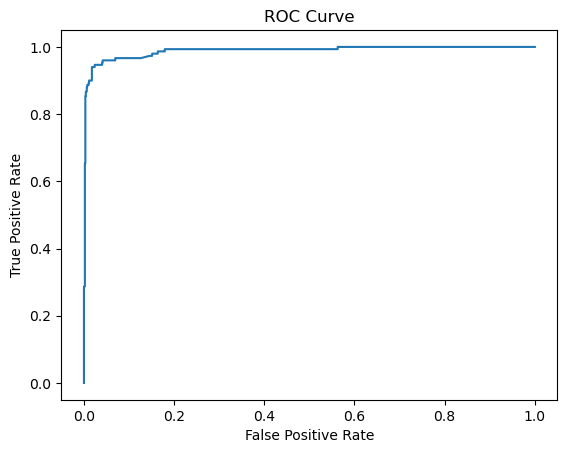

AUC Score: 0.9884628670120899


In [20]:
from sklearn.metrics import roc_curve, auc

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

print("AUC Score:", roc_auc)

In [21]:
import joblib

joblib.dump(model, "spam_detector_model.pkl")

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!


In [22]:
def predict_message(msg):
    
    msg_clean = clean_text(msg)
    
    msg_vector = vectorizer.transform([msg_clean])
    
    prediction = model.predict(msg_vector)
    
    if prediction[0] == 1:
        return "⚠️ Spam Detected"
    else:
        return "✅ Normal Message"

# Test examples

print(predict_message("Win ₹50,000 now!!!"))

print(predict_message("Are we meeting today?"))

⚠️ Spam Detected
✅ Normal Message


In [23]:
from sklearn.linear_model import LogisticRegression

# Balanced Logistic Regression

model = LogisticRegression(
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("Balanced Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Balanced Accuracy: 0.9775784753363229
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.93      0.90      0.92       150

    accuracy                           0.98      1115
   macro avg       0.96      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [24]:
import joblib

joblib.dump(model, "spam_detector_model.pkl")

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model saved successfully!")

Model saved successfully!
